**Assignment - EDA using Pandas**

***Instructions***
- Clone a copy of the assignment notebook in Google Colab.
- **Complete the tasks by filling in the code where indicated by TODO comments. Put each task in a new cell.**
- Run each cell to ensure your code works correctly.
- Pay attention to the output of each cell and interpret the results.
- For visualisation tasks, make sure to label axes, add titles, and choose appropriate colour schemes.
- After completing all tasks, review your findings and include notes of your insights gained from the EDA process as markdown notes for assessments.


# Titanic Dataset Exploratory Data Analysis

In [ ]:
# Import necessary libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)


In [ ]:
# Task 1: Load the Titanic dataset from file provided

possible_paths = [
    "/content/Titanic-Dataset.csv",
    "/content/Titanic-Dataset (1)(1).csv",
    "Titanic-Dataset.csv",
    "Titanic-Dataset (1)(1).csv",
    "/mnt/data/Titanic-Dataset (1)(1).csv"
]

data_path = None
for path in possible_paths:
    if os.path.exists(path):
        data_path = path
        break

if data_path is None:
    raise FileNotFoundError("Titanic dataset file was not found. Upload the CSV file to Colab and try again.")

df = pd.read_csv(data_path)
print("Dataset loaded from:", data_path)
print("Shape:", df.shape)


Dataset loaded from: Titanic-Dataset (1)(1).csv
Shape: (891, 12)


In [ ]:
# Task 2: Inspect the data

print("First 5 rows:")
display(df.head())

print("Last 5 rows:")
display(df.tail())

print("Data types:")
display(df.dtypes)

print("Summary statistics:")
display(df.describe(include="all"))


First 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Last 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


Data types:


PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Summary statistics:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,1601,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


## Notes
The dataset contains passenger information such as class, sex, age, fare, and survival outcome.  
At the inspection stage, we can already see that some fields such as **Age** and **Cabin** contain missing values and will need preprocessing before analysis.


In [ ]:
# Task 3: Clean and preprocess the data

# Create a new categorical feature 'PclassCategory' from 'Pclass'
pclass_map = {1: "First Class", 2: "Second Class", 3: "Third Class"}
df["PclassCategory"] = df["Pclass"].map(pclass_map)

# Create a new categorical feature 'CabinCategory' from 'Cabin'
df["CabinCategory"] = df["Cabin"].fillna("Unknown").astype(str).str[0]
df["CabinCategory"] = df["CabinCategory"].replace("U", "Unknown")

# Handle missing values in the 'Age' column using mean age
age_mean = df["Age"].mean()
df["Age"] = df["Age"].fillna(age_mean)

# Create a 'Family' feature by combining 'SibSp' and 'Parch'
df["Family"] = df["SibSp"] + df["Parch"]

print("Missing values after preprocessing:")
display(df.isnull().sum())

print("Updated data sample:")
display(df.head())


Missing values after preprocessing:


PassengerId         0
Survived            0
Pclass              0
Name                0
Sex                 0
Age                 0
SibSp               0
Parch               0
Ticket              0
Fare                0
Cabin             687
Embarked            2
PclassCategory      0
CabinCategory       0
Family              0
dtype: int64

Updated data sample:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,PclassCategory,CabinCategory,Family
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Third Class,Unknown,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,First Class,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Third Class,Unknown,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,First Class,C,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Third Class,Unknown,0


## Notes
- **Age** missing values were filled with the mean age so numerical analysis could continue without dropping rows.
- **PclassCategory** makes passenger class easier to interpret.
- **CabinCategory** groups cabins by deck letter and marks missing cabin values as **Unknown**.
- **Family** helps analyze whether travelling with relatives affected survival.


In [ ]:
# Task 4: Identify specific data points

highest_fare_passengers = df[df["Fare"] == df["Fare"].max()]
largest_family_passengers = df[df["Family"] == df["Family"].max()]

print("Passenger(s) with the highest fare:")
display(highest_fare_passengers[["Name", "Pclass", "Sex", "Age", "Fare", "Survived"]])

print("Passenger(s) with the largest family size:")
display(largest_family_passengers[["Name", "Pclass", "Sex", "Age", "Family", "Survived"]])


Passenger(s) with the highest fare:


,Name,Pclass,Sex,Age,Fare,Survived
258,"Ward, Miss. Anna",1,female,35.0,512.3292,1
679,"Cardeza, Mr. Thomas Drake Martinez",1,male,36.0,512.3292,1
737,"Lesurer, Mr. Gustave J",1,male,35.0,512.3292,1


Passenger(s) with the largest family size:


,Name,Pclass,Sex,Age,Family,Survived
159,"Sage, Master. Thomas Henry",3,male,29.699118,10,0
180,"Sage, Miss. Constance Gladys",3,female,29.699118,10,0
201,"Sage, Mr. Frederick",3,male,29.699118,10,0
324,"Sage, Mr. George John Jr",3,male,29.699118,10,0
792,"Sage, Miss. Stella Anna",3,female,29.699118,10,0
846,"Sage, Mr. Douglas Bullen",3,male,29.699118,10,0
863,"Sage, Miss. Dorothy Edith ""Dolly""",3,female,29.699118,10,0


In [ ]:
# Task 5: Demonstrate Pandas Series and DataFrame functionalities

# Create and manipulate a Series
age_series = pd.Series(df["Age"].head(10).values, name="SampleAge")
print("Sample Pandas Series:")
display(age_series)

# Create and manipulate a DataFrame
sample_df = pd.DataFrame({
    "PassengerName": df["Name"].head(5),
    "PassengerClass": df["PclassCategory"].head(5),
    "Fare": df["Fare"].head(5)
})
print("Sample Pandas DataFrame:")
display(sample_df)

# Indexing and slicing operations
print("Single column selection (Sex):")
display(df["Sex"].head())

print("Multiple column selection (Name, Age, Fare):")
display(df[["Name", "Age", "Fare"]].head())

print("Row slicing (rows 0 to 4):")
display(df.iloc[0:5])

print("Row and column slicing (first 5 rows, selected columns):")
display(df.iloc[0:5, 1:6])


Sample Pandas Series:


0    22.000000
1    38.000000
2    26.000000
3    35.000000
4    35.000000
5    29.699118
6    54.000000
7     2.000000
8    27.000000
9    14.000000
Name: SampleAge, dtype: float64

Sample Pandas DataFrame:


,PassengerName,PassengerClass,Fare
0,"Braund, Mr. Owen Harris",Third Class,7.2500
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",First Class,71.2833
2,"Heikkinen, Miss. Laina",Third Class,7.9250
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",First Class,53.1000
4,"Allen, Mr. William Henry",Third Class,8.0500


Single column selection (Sex):


...

,Name,Age,Fare
0,"Braund, Mr. Owen Harris",22.0,7.2500
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,71.2833
2,"Heikkinen, Miss. Laina",26.0,7.9250
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,53.1000
4,"Allen, Mr. William Henry",35.0,8.0500


Row slicing (rows 0 to 4):


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,PclassCategory,CabinCategory,Family
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Third Class,Unknown,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,First Class,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Third Class,Unknown,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,First Class,C,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Third Class,Unknown,0


Row and column slicing (first 5 rows, selected columns):


,Survived,Pclass,Name,Sex,Age
0,0,3,"Braund, Mr. Owen Harris",male,22.0
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0
2,1,3,"Heikkinen, Miss. Laina",female,26.0
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0
4,0,3,"Allen, Mr. William Henry",male,35.0


In [ ]:
# Task 6: Multi-indexing - survival rates by Sex and Pclass

survival_multiindex = df.groupby(["Sex", "Pclass"])["Survived"].mean().to_frame("SurvivalRate")
display(survival_multiindex)


SurvivalRate
Sex    Pclass              
female 1           0.968085
       2           0.921053
       3           0.500000
male   1           0.368852
       2           0.157407
       3           0.135447

## Notes
The multi-index table makes it easier to compare survival rates across both **sex** and **passenger class** at the same time.  
This is useful because survival on the Titanic was strongly related to both social class and gender.


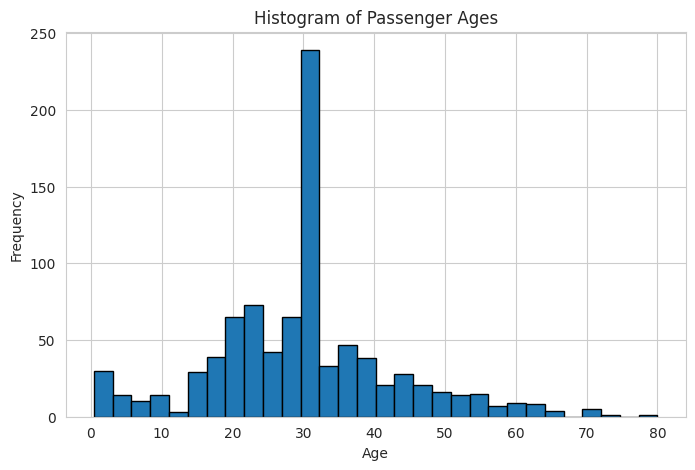

In [ ]:
# Task 7: Histogram of passenger ages

plt.figure(figsize=(8, 5))
plt.hist(df["Age"], bins=30, edgecolor="black")
plt.title("Histogram of Passenger Ages")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()


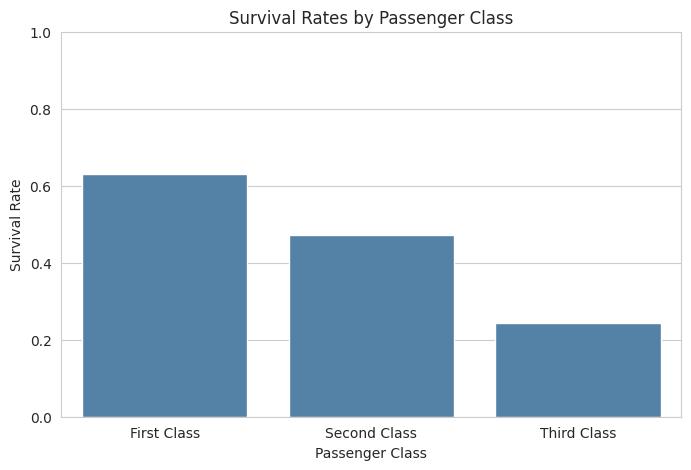

,PclassCategory,SurvivalRate
0,First Class,0.629630
1,Second Class,0.472826
2,Third Class,0.242363


In [ ]:
# Task 8: Bar plot of survival rates by passenger class

survival_by_class = df.groupby("PclassCategory", as_index=False)["Survived"].mean()
survival_by_class["PclassCategory"] = pd.Categorical(
    survival_by_class["PclassCategory"],
    categories=["First Class", "Second Class", "Third Class"],
    ordered=True
)
survival_by_class = survival_by_class.sort_values("PclassCategory")

plt.figure(figsize=(8, 5))
sns.barplot(data=survival_by_class, x="PclassCategory", y="Survived", color="steelblue")
plt.title("Survival Rates by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.show()

display(survival_by_class.rename(columns={"Survived": "SurvivalRate"}))


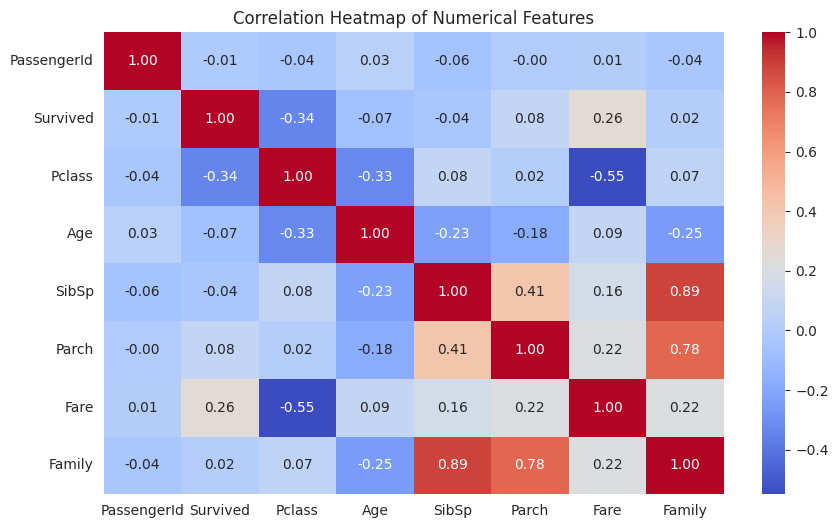

In [ ]:
# Task 9: Heatmap of correlations between numerical features

numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr(numeric_only=True)

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()


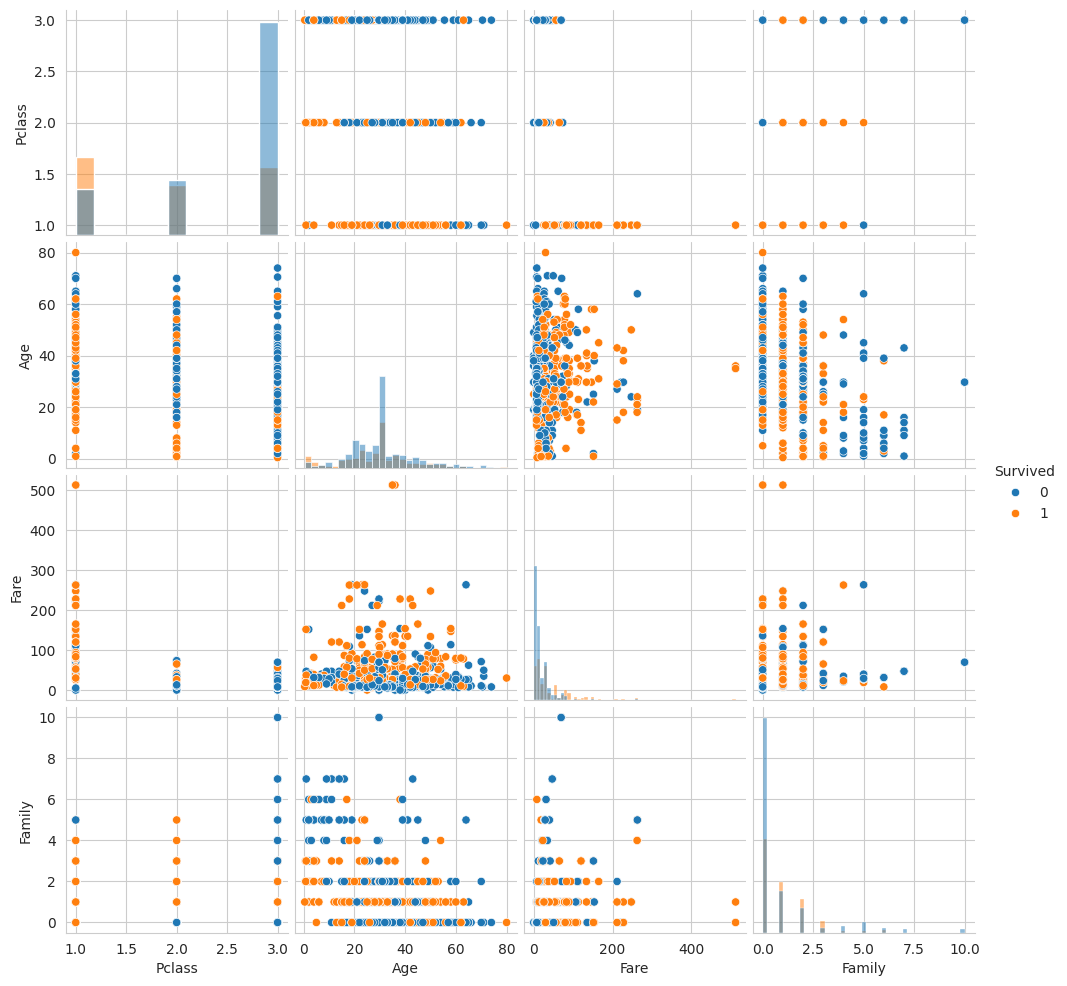

In [ ]:
# Task 10: Pair plot of selected features

selected_features = df[["Survived", "Pclass", "Age", "Fare", "Family"]]
sns.pairplot(selected_features, hue="Survived", diag_kind="hist")
plt.show()


Survival rate by sex:


,Sex,SurvivalRate
0,female,0.742038
1,male,0.188908


Survival rate by sex and passenger class:


,Sex,PclassCategory,SurvivalRate
0,female,First Class,0.968085
1,female,Second Class,0.921053
2,female,Third Class,0.500000
3,male,First Class,0.368852
4,male,Second Class,0.157407
5,male,Third Class,0.135447


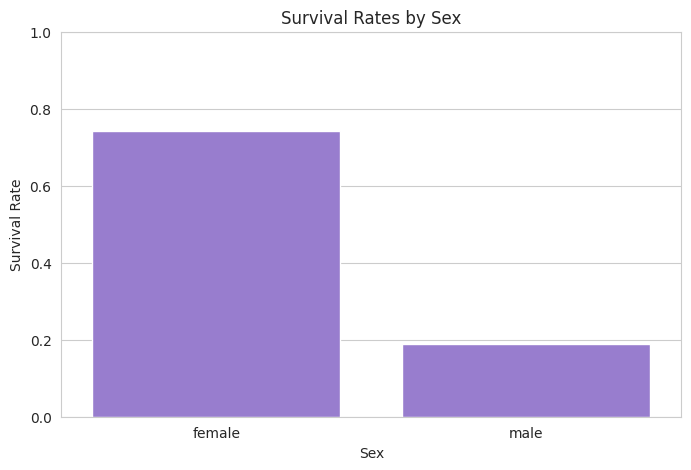

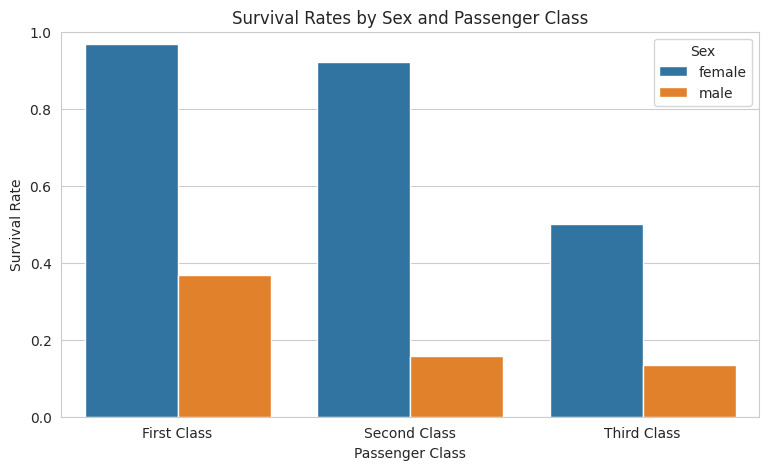

In [ ]:
# Task 11: Analyze survival rates by sex and passenger class

survival_by_sex = df.groupby("Sex", as_index=False)["Survived"].mean().sort_values("Survived", ascending=False)
survival_by_sex_class = df.groupby(["Sex", "PclassCategory"], as_index=False)["Survived"].mean()

print("Survival rate by sex:")
display(survival_by_sex.rename(columns={"Survived": "SurvivalRate"}))

print("Survival rate by sex and passenger class:")
display(survival_by_sex_class.rename(columns={"Survived": "SurvivalRate"}))

plt.figure(figsize=(8, 5))
sns.barplot(data=survival_by_sex, x="Sex", y="Survived", color="mediumpurple")
plt.title("Survival Rates by Sex")
plt.xlabel("Sex")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.show()

plt.figure(figsize=(9, 5))
sns.barplot(data=survival_by_sex_class, x="PclassCategory", y="Survived", hue="Sex", order=["First Class", "Second Class", "Third Class"])
plt.title("Survival Rates by Sex and Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.show()


## Notes
- Females had a much higher survival rate than males.
- Passengers in **First Class** had better survival outcomes than those in **Second Class** and **Third Class**.
- The combination of being **female** and in **First Class** appears to show the strongest survival advantage.


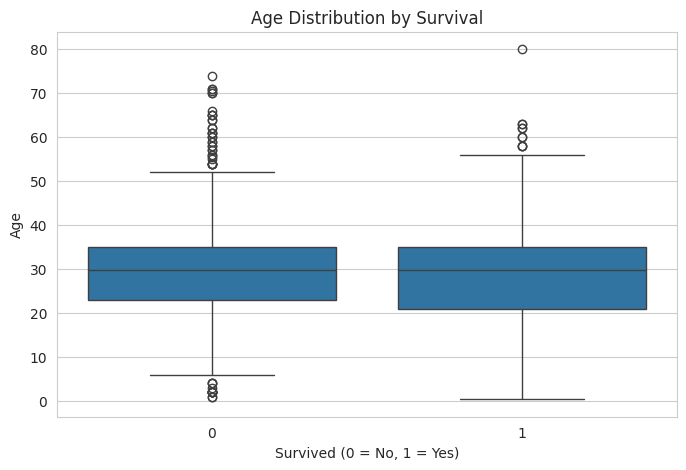

In [ ]:
# Task 12: Analyze age distribution using a box plot

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Survived", y="Age")
plt.title("Age Distribution by Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Age")
plt.show()


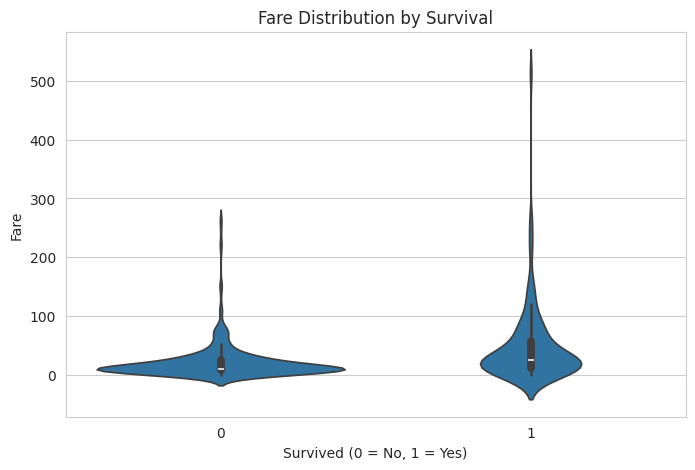

In [ ]:
# Task 13: Analyze fare distribution using a violin plot

plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x="Survived", y="Fare")
plt.title("Fare Distribution by Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Fare")
plt.show()


## Final EDA Insights
1. The dataset required preprocessing mainly because of missing values in **Age** and many unknown entries in **Cabin**.
2. Survival was clearly influenced by **sex** and **passenger class**.
3. Female passengers survived at much higher rates than male passengers.
4. First-class passengers had the best survival chances, while third-class passengers had the lowest.
5. Fare appears positively related to survival, suggesting wealthier passengers had better chances.
6. Age distribution shows that survivors and non-survivors overlap, but children and younger passengers may have had some advantage.
7. Family size varies widely, and very large family groups were less common.


## Links

- Colab notebook link: https://drive.google.com/file/d/12_uNBI4uXmQ4cRWbSDG8r9Re-Ag1uJi4/view?usp=sharing
- GitHub repository link: